# 08 - Synthetic benchmark v0.2: conditional revision validation

## tl;dr

This notebook validates the v0.2 conditional-revision generator against the
failing diagnostics from `07_synthetic_conditional_fidelity_validation.ipynb`.
It compares the previous `v0_1_provisional` central pilot with the new
`v0_2_conditional_revision` central pilot.

The acceptance criteria are defined before interpreting results:

- weighted mean absolute error (WMAE) <= 3 percentage points;
- median absolute error <= 5 percentage points;
- 90th percentile absolute error <= 12 percentage points;
- absolute weighted signed bias <= 3 percentage points;
- maximum absolute error <= 30 percentage points, or the maximum-error cell is
  sparse/low-impact and documented.

The revision is intended to tune only observable real-data properties:
SIRET availability, duration-field availability, and exact cross-buyer text
reuse. It does not tune CPV missingness, latent recurrence truth, or any
linkage score/threshold output.


## Context & Methods

Sources:

- Real corpus: `data/interim/boamp_common_prepared.csv`
- Previous synthetic: `data/processed/synthetic_benchmark/v0_1_provisional/central_provisional/world_001/corruption_001`
- Revised synthetic: `data/processed/synthetic_benchmark/v0_2_conditional_revision/central_provisional/world_001/corruption_001`
- Conditional parameters:
  `reports/tables/synthetic_benchmark/v0_2_conditional_revision/conditional_observation_parameters.csv`

Metrics use real-cell sample sizes as weights:

`WMAE = sum(n_real * abs(p_synthetic - p_real)) / sum(n_real)`

Confidence intervals remain in detailed cell tables, but pass/fail uses the
weighted summaries above because the real corpus is large and many real
intervals are very narrow.


## Setup

In [1]:
import json
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors

from boamp.reporting.figures import setup_style
from boamp.synthetic.compatibility import adapt_observed_notices_to_sources
from utils.text_clean import normalize_objet

setup_style()

REAL_PATH = PROJECT_ROOT / "data/interim/boamp_common_prepared.csv"
VERSIONS = {
    "v0_1_provisional": PROJECT_ROOT / "data/processed/synthetic_benchmark/v0_1_provisional/central_provisional/world_001/corruption_001",
    "v0_2_conditional_revision": PROJECT_ROOT / "data/processed/synthetic_benchmark/v0_2_conditional_revision/central_provisional/world_001/corruption_001",
}

OUT_TABLES = PROJECT_ROOT / "reports/tables/synthetic_benchmark/v0_2_conditional_revision"
OUT_FIGURES = PROJECT_ROOT / "reports/figures/synthetic_benchmark/v0_2_conditional_revision"
OUT_REPORT = PROJECT_ROOT / "reports/generated/synthetic_benchmark/v0_2_conditional_revision_report.md"
OUT_TABLES.mkdir(parents=True, exist_ok=True)
OUT_FIGURES.mkdir(parents=True, exist_ok=True)
OUT_REPORT.parent.mkdir(parents=True, exist_ok=True)

COLOR_BEFORE = "#9a9a95"
COLOR_AFTER = "#2a78d6"
DIVERGING_CMAP = "RdBu_r"

ACCEPTANCE = {
    "wmae_pp_max": 3.0,
    "median_abs_pp_max": 5.0,
    "p90_abs_pp_max": 12.0,
    "abs_weighted_bias_pp_max": 3.0,
    "max_abs_pp_max": 30.0,
}
pd.DataFrame([ACCEPTANCE]).to_csv(OUT_TABLES / "conditional_fidelity_acceptance_criteria.csv", index=False)
ACCEPTANCE

{'wmae_pp_max': 3.0,
 'median_abs_pp_max': 5.0,
 'p90_abs_pp_max': 12.0,
 'abs_weighted_bias_pp_max': 3.0,
 'max_abs_pp_max': 30.0}

## Load and Prepare Data

In [2]:
REAL_USECOLS = [
    "notice_id", "schema_family", "notice_type_normalized", "publication_year",
    "buyer_siret_clean", "cpv_clean", "cpv_division", "duration_raw",
    "objet_normalized", "objet_clean", "buyer_key",
]


def add_common_flags(frame: pd.DataFrame, id_col: str) -> pd.DataFrame:
    out = frame.copy()
    counts = out.groupby("buyer_key", dropna=False)[id_col].transform("size")
    out["buyer_activity_tier"] = pd.cut(
        counts, bins=[0, 1, 5, 20, np.inf],
        labels=["1 (single)", "2-5", "6-20", "21+"],
        right=True,
    ).astype(str)
    text_stats = (
        out.dropna(subset=["objet_normalized"])
        .groupby("objet_normalized")
        .agg(n_notices=("objet_normalized", "size"), n_buyers=("buyer_key", "nunique"))
    )
    generic_texts = set(text_stats.query("n_notices >= 2 and n_buyers >= 2").index)
    within_buyer_texts = set(
        out.dropna(subset=["objet_normalized", "buyer_key"])
        .groupby(["buyer_key", "objet_normalized"])
        .size()
        .loc[lambda s: s >= 2]
        .index.get_level_values("objet_normalized")
    )
    out["generic_text"] = out["objet_normalized"].isin(generic_texts)
    out["within_buyer_duplicate_text"] = out["objet_normalized"].isin(within_buyer_texts)
    out["siret_present"] = out["buyer_siret_clean"].notna()
    out["cpv_missing"] = out["cpv_clean"].isna()
    out["duration_present"] = out["duration_raw"].notna()
    return out


real = pd.read_csv(REAL_PATH, usecols=REAL_USECOLS, low_memory=False)
real = add_common_flags(real, "notice_id")


def load_synthetic(path: Path) -> pd.DataFrame:
    observed = pd.read_parquet(path / "observed_notices.parquet")
    adapted = adapt_observed_notices_to_sources(observed)
    adapted["publication_year"] = pd.to_datetime(adapted["publication_date"]).dt.year
    adapted["duration_raw"] = observed["declared_duration_months"]
    adapted["objet_normalized"] = adapted["objet_clean"].map(normalize_objet)
    return add_common_flags(adapted, "notice_id")


synthetic = {version: load_synthetic(path) for version, path in VERSIONS.items()}
pd.DataFrame({
    "dataset": ["real", *synthetic.keys()],
    "n_rows": [len(real), *[len(df) for df in synthetic.values()]],
    "siret_present": [real["siret_present"].mean(), *[df["siret_present"].mean() for df in synthetic.values()]],
    "duration_present": [real["duration_present"].mean(), *[df["duration_present"].mean() for df in synthetic.values()]],
    "cpv_missing": [real["cpv_missing"].mean(), *[df["cpv_missing"].mean() for df in synthetic.values()]],
    "generic_text": [real["generic_text"].mean(), *[df["generic_text"].mean() for df in synthetic.values()]],
})

,dataset,n_rows,siret_present,duration_present,cpv_missing,generic_text
0,real,84623,0.272243,0.136452,0.170616,0.078395
1,v0_1_provisional,9537,0.288665,0.180770,0.151410,0.537171
2,v0_2_conditional_revision,9607,0.302384,0.151973,0.149370,0.084730


## Conditional Comparisons

In [3]:
def wilson_interval(successes: pd.Series, n: pd.Series, z: float = 1.96) -> tuple[pd.Series, pd.Series]:
    successes = successes.astype(float)
    n = n.astype(float)
    phat = successes / n
    denom = 1 + z**2 / n
    centre = (phat + z**2 / (2 * n)) / denom
    margin = z * np.sqrt((phat * (1 - phat) / n) + (z**2 / (4 * n**2))) / denom
    return (centre - margin).clip(0, 1), (centre + margin).clip(0, 1)


def rates(frame: pd.DataFrame, outcome: str, group_cols: list[str]) -> pd.DataFrame:
    out = frame.groupby(group_cols, dropna=False)[outcome].agg(successes="sum", n="count").reset_index()
    out["rate"] = out["successes"] / out["n"]
    out["ci_low"], out["ci_high"] = wilson_interval(out["successes"], out["n"])
    return out


def compare_version(version: str, outcome: str, group_cols: list[str], target: str) -> pd.DataFrame:
    real_rates = rates(real, outcome, group_cols)
    syn_rates = rates(synthetic[version], outcome, group_cols)
    comp = real_rates.merge(syn_rates, on=group_cols, how="outer", suffixes=("_real", "_synthetic"))
    comp.insert(0, "version", version)
    comp.insert(1, "target", target)
    comp["diff_pp"] = (comp["rate_synthetic"] - comp["rate_real"]) * 100
    comp["abs_diff_pp"] = comp["diff_pp"].abs()
    comp["ci_overlap"] = (
        comp["ci_low_real"].le(comp["ci_high_synthetic"])
        & comp["ci_low_synthetic"].le(comp["ci_high_real"])
    )
    comp["eligible_cell"] = comp["n_real"].fillna(0).ge(30) & comp["n_synthetic"].fillna(0).ge(30)
    return comp


TARGETS = {
    "siret_present": ("siret_present", ["schema_family", "publication_year", "notice_type_normalized"]),
    "cpv_missing": ("cpv_missing", ["schema_family", "notice_type_normalized"]),
    "duration_present": ("duration_present", ["schema_family", "publication_year", "notice_type_normalized"]),
    "generic_repeated_text": ("generic_text", ["notice_type_normalized", "buyer_activity_tier"]),
}

all_comparisons = []
for target, (outcome, group_cols) in TARGETS.items():
    for version in synthetic:
        comp = compare_version(version, outcome, group_cols, target)
        comp.to_csv(OUT_TABLES / f"conditional_fidelity_{target}_{version}.csv", index=False)
        all_comparisons.append(comp)

all_comparisons = pd.concat(all_comparisons, ignore_index=True, sort=False)
all_comparisons.to_csv(OUT_TABLES / "conditional_fidelity_all_cells_by_version.csv", index=False)
all_comparisons.head()

,version,target,schema_family,publication_year,notice_type_normalized,successes_real,n_real,rate_real,ci_low_real,ci_high_real,successes_synthetic,n_synthetic,rate_synthetic,ci_low_synthetic,ci_high_synthetic,diff_pp,abs_diff_pp,ci_overlap,eligible_cell,buyer_activity_tier
0,v0_1_provisional,siret_present,EFORMS,2024.0,APPEL_OFFRE,2318,2638,0.878696,0.865683,0.890607,175.0,404.0,0.433168,0.385702,0.481893,-44.552766,44.552766,False,True,NaN
1,v0_1_provisional,siret_present,EFORMS,2024.0,ATTRIBUTION,1241,1399,0.887062,0.869405,0.902599,65.0,139.0,0.467626,0.386667,0.550326,-41.943629,41.943629,False,True,NaN
2,v0_1_provisional,siret_present,EFORMS,2024.0,OTHER,24,26,0.923077,0.758581,0.978645,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,NaN
3,v0_1_provisional,siret_present,EFORMS,2025.0,APPEL_OFFRE,2033,2817,0.721690,0.704846,0.737929,155.0,354.0,0.437853,0.387112,0.489929,-28.383663,28.383663,False,True,NaN
4,v0_1_provisional,siret_present,EFORMS,2025.0,ATTRIBUTION,1014,1539,0.658869,0.634814,0.682134,70.0,147.0,0.476190,0.397092,0.556502,-18.267892,18.267892,False,True,NaN


### Weighted Summary Metrics

In [4]:
def summarize(comp: pd.DataFrame) -> pd.Series:
    eligible = comp[comp["eligible_cell"]].copy()
    real_total = comp["n_real"].fillna(0).sum()
    eligible_real_total = eligible["n_real"].fillna(0).sum()
    weights = eligible["n_real"] / eligible_real_total if eligible_real_total else np.nan
    weighted_abs = float((weights * eligible["abs_diff_pp"]).sum()) if eligible_real_total else np.nan
    weighted_bias = float((weights * eligible["diff_pp"]).sum()) if eligible_real_total else np.nan
    max_row = eligible.sort_values("abs_diff_pp", ascending=False).head(1)
    max_real_share = float(max_row["n_real"].iloc[0] / real_total) if len(max_row) and real_total else np.nan
    return pd.Series({
        "eligible_cells": int(eligible.shape[0]),
        "total_cells": int(comp.shape[0]),
        "eligible_real_population_share": eligible_real_total / real_total if real_total else np.nan,
        "weighted_mean_abs_error_pp": weighted_abs,
        "unweighted_mean_abs_error_pp": float(eligible["abs_diff_pp"].mean()) if len(eligible) else np.nan,
        "median_abs_error_pp": float(eligible["abs_diff_pp"].median()) if len(eligible) else np.nan,
        "p90_abs_error_pp": float(eligible["abs_diff_pp"].quantile(0.9)) if len(eligible) else np.nan,
        "max_abs_error_pp": float(eligible["abs_diff_pp"].max()) if len(eligible) else np.nan,
        "weighted_signed_bias_pp": weighted_bias,
        "max_error_real_population_share": max_real_share,
    })


summary = (
    all_comparisons
    .groupby(["target", "version"], dropna=False)
    .apply(summarize, include_groups=False)
    .reset_index()
)

def assess(row: pd.Series) -> str:
    checks = [
        row["weighted_mean_abs_error_pp"] <= ACCEPTANCE["wmae_pp_max"],
        row["median_abs_error_pp"] <= ACCEPTANCE["median_abs_pp_max"],
        row["p90_abs_error_pp"] <= ACCEPTANCE["p90_abs_pp_max"],
        abs(row["weighted_signed_bias_pp"]) <= ACCEPTANCE["abs_weighted_bias_pp_max"],
        row["max_abs_error_pp"] <= ACCEPTANCE["max_abs_pp_max"],
    ]
    return "PASS" if all(checks) else "NEEDS_REVISION"

summary["assessment"] = summary.apply(assess, axis=1)
summary.to_csv(OUT_TABLES / "conditional_fidelity_summary_by_version.csv", index=False)

before_after = summary.pivot(index="target", columns="version", values="weighted_mean_abs_error_pp").reset_index()
before_after["wmae_improvement_pp"] = before_after["v0_1_provisional"] - before_after["v0_2_conditional_revision"]
before_after.to_csv(OUT_TABLES / "conditional_fidelity_before_after_wmae.csv", index=False)
summary

,target,version,eligible_cells,total_cells,eligible_real_population_share,weighted_mean_abs_error_pp,unweighted_mean_abs_error_pp,median_abs_error_pp,p90_abs_error_pp,max_abs_error_pp,weighted_signed_bias_pp,max_error_real_population_share,assessment
0,cpv_missing,v0_1_provisional,4.0,6.0,0.955438,2.362367,1.653337,1.356996,2.571195,3.038216,-2.078288,0.608239,PASS
1,cpv_missing,v0_2_conditional_revision,4.0,6.0,0.955438,2.574946,1.931960,1.612458,2.701881,3.128718,-2.200784,0.608239,PASS
2,duration_present,v0_1_provisional,29.0,45.0,0.934935,11.695043,14.965859,6.015281,51.592638,68.002324,2.854978,0.016532,NEEDS_REVISION
3,duration_present,v0_2_conditional_revision,29.0,45.0,0.934935,0.508675,0.960956,0.452489,2.575909,5.566939,0.133872,0.016532,PASS
4,generic_repeated_text,v0_1_provisional,8.0,12.0,0.955438,59.141260,46.276272,42.785352,63.714018,67.107928,59.141260,0.228968,NEEDS_REVISION
5,generic_repeated_text,v0_2_conditional_revision,8.0,12.0,0.955438,1.397535,4.265915,0.896527,10.673826,25.532751,1.003554,0.002872,PASS
6,siret_present,v0_1_provisional,29.0,45.0,0.934935,12.431117,19.886204,11.174973,44.785137,58.441558,-1.921104,0.002328,NEEDS_REVISION
7,siret_present,v0_2_conditional_revision,29.0,45.0,0.934935,1.881034,2.163014,2.153665,3.782112,9.724865,-0.476764,0.010033,PASS


### Worst Supported Cells

In [5]:
worst_cells = (
    all_comparisons[all_comparisons["eligible_cell"]]
    .sort_values(["target", "version", "abs_diff_pp"], ascending=[True, True, False])
    .groupby(["target", "version"], as_index=False)
    .head(10)
)
worst_cells.to_csv(OUT_TABLES / "conditional_fidelity_worst_supported_cells.csv", index=False)
worst_cells[[
    "target", "version", "schema_family", "publication_year", "notice_type_normalized",
    "buyer_activity_tier", "n_real", "n_synthetic", "rate_real", "rate_synthetic",
    "diff_pp", "abs_diff_pp",
]].head(20)

,target,version,schema_family,publication_year,notice_type_normalized,buyer_activity_tier,n_real,n_synthetic,rate_real,rate_synthetic,diff_pp,abs_diff_pp
93,cpv_missing,v0_1_provisional,LEGACY,NaN,APPEL_OFFRE,NaN,51471,5985.0,0.242078,0.211696,-3.038216,3.038216
91,cpv_missing,v0_1_provisional,EFORMS,NaN,ATTRIBUTION,NaN,3787,405.0,0.000000,0.014815,1.481481,1.481481
94,cpv_missing,v0_1_provisional,LEGACY,NaN,ATTRIBUTION,NaN,18773,2218.0,0.085815,0.073490,-1.232510,1.232510
90,cpv_missing,v0_1_provisional,EFORMS,NaN,APPEL_OFFRE,NaN,6821,929.0,0.000000,0.008611,0.861141,0.861141
99,cpv_missing,v0_2_conditional_revision,LEGACY,NaN,APPEL_OFFRE,NaN,51471,5968.0,0.242078,0.210791,-3.128718,3.128718
100,cpv_missing,v0_2_conditional_revision,LEGACY,NaN,ATTRIBUTION,NaN,18773,2298.0,0.085815,0.068755,-1.705929,1.705929
97,cpv_missing,v0_2_conditional_revision,EFORMS,NaN,ATTRIBUTION,NaN,3787,395.0,0.000000,0.015190,1.518987,1.518987
96,cpv_missing,v0_2_conditional_revision,EFORMS,NaN,APPEL_OFFRE,NaN,6821,946.0,0.000000,0.013742,1.374207,1.374207
103,duration_present,v0_1_provisional,EFORMS,2024.0,ATTRIBUTION,NaN,1399,139.0,0.248034,0.928058,68.002324,68.002324
144,duration_present,v0_1_provisional,LEGACY,2026.0,APPEL_OFFRE,NaN,1130,137.0,0.631858,0.043796,-58.806279,58.806279


### Heatmaps and Before/After Chart

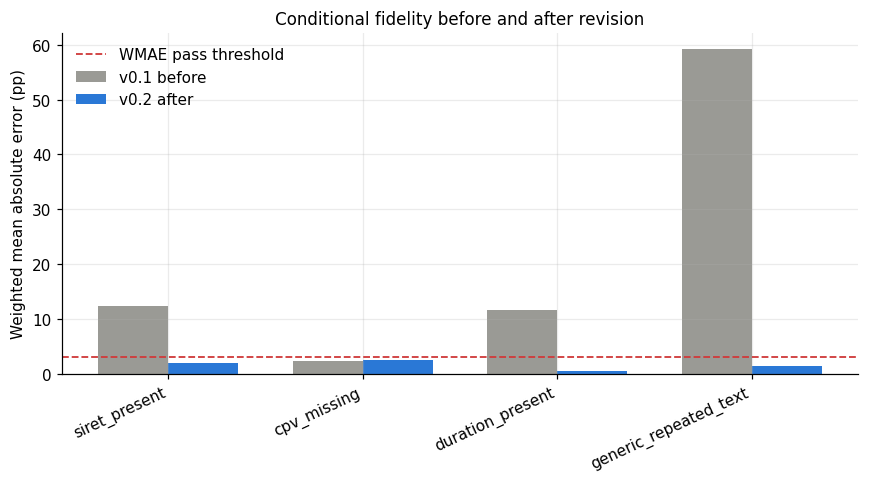

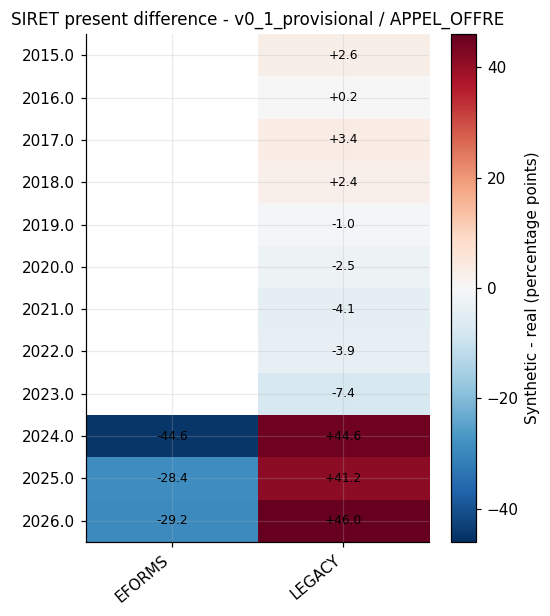

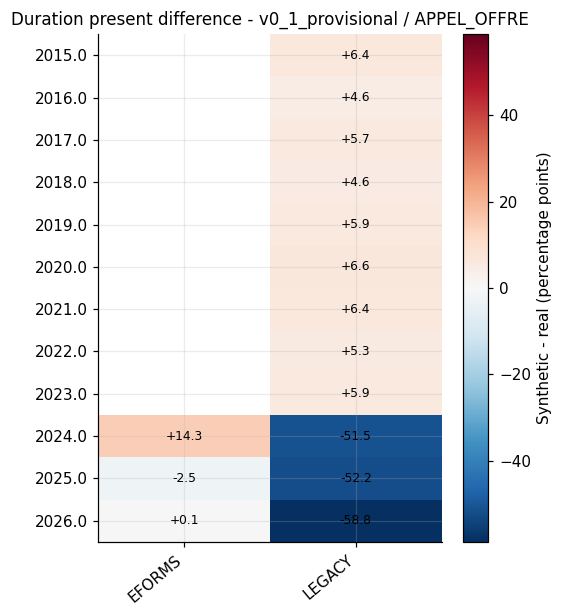

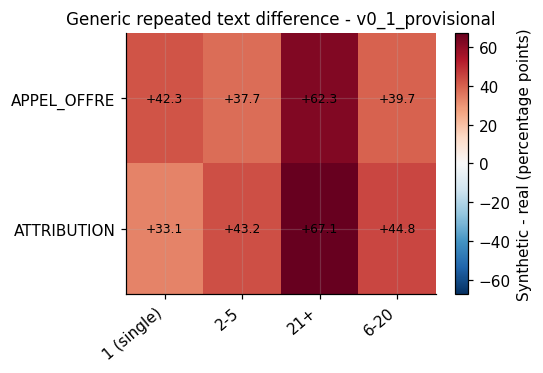

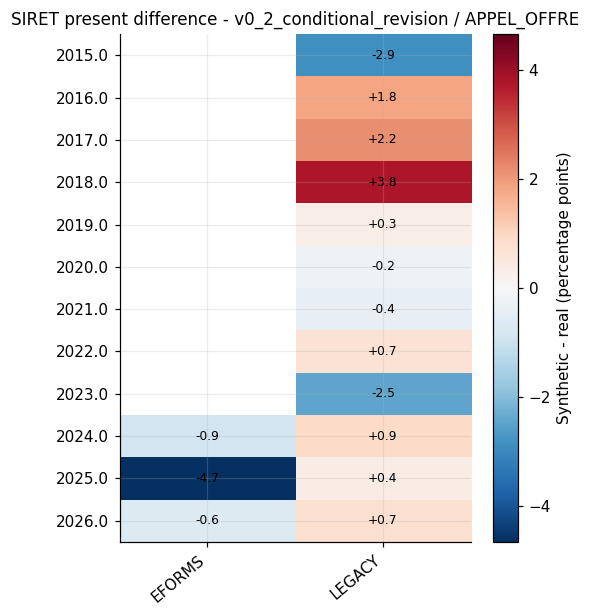

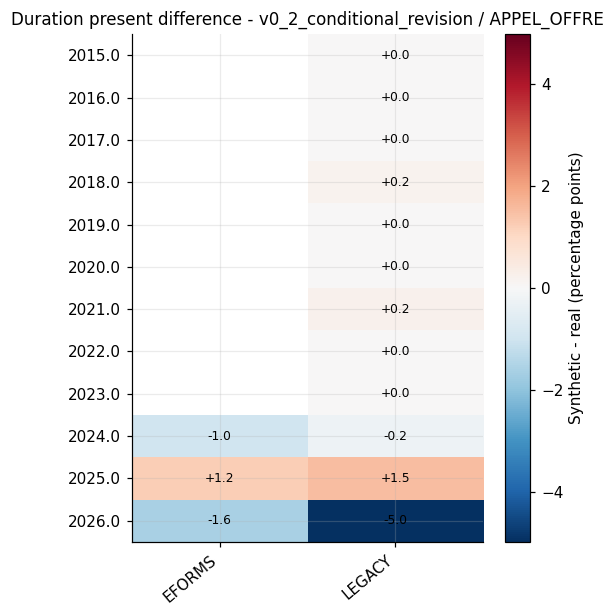

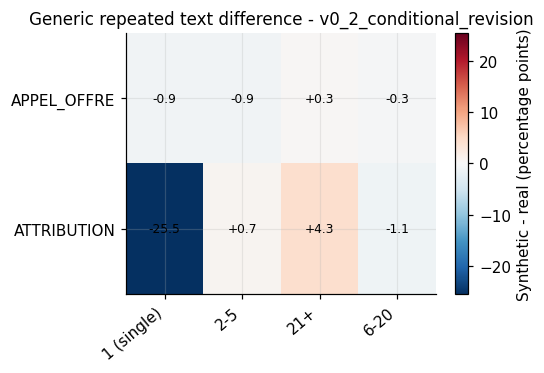

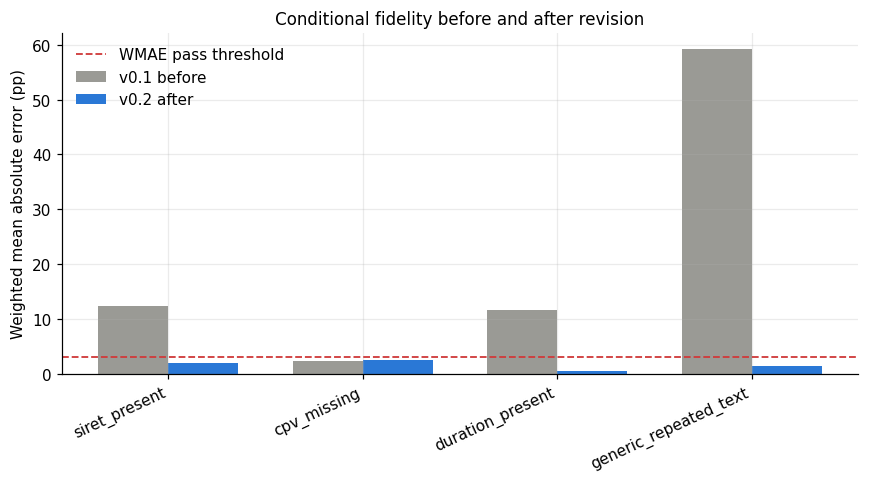

In [6]:
def save_heatmap(comp: pd.DataFrame, row: str, col: str, title: str, filename: str, filters: dict | None = None):
    plot_df = comp.copy()
    if filters:
        for key, value in filters.items():
            plot_df = plot_df[plot_df[key].eq(value)]
    pivot = plot_df.pivot_table(index=row, columns=col, values="diff_pp", aggfunc="mean")
    fig, ax = plt.subplots(figsize=(max(5, len(pivot.columns) * 0.7 + 2), max(3.5, len(pivot.index) * 0.35 + 1.5)))
    vmax = max(1.0, float(np.nanmax(np.abs(pivot.values))))
    im = ax.imshow(pivot.values, cmap=DIVERGING_CMAP, norm=TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax), aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=40, ha="right")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_title(title)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.iloc[i, j]
            if pd.notna(val):
                ax.text(j, i, f"{val:+.1f}", ha="center", va="center", fontsize=8)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Synthetic - real (percentage points)")
    fig.tight_layout()
    fig.savefig(OUT_FIGURES / f"{filename}.png", bbox_inches="tight", dpi=150)
    fig.savefig(OUT_FIGURES / f"{filename}.pdf", bbox_inches="tight")
    return fig


for version in synthetic:
    sub = all_comparisons[all_comparisons["version"].eq(version)]
    save_heatmap(
        sub[sub["target"].eq("siret_present")], "publication_year", "schema_family",
        f"SIRET present difference - {version} / APPEL_OFFRE",
        f"conditional_fidelity_siret_appel_offre_{version}",
        {"notice_type_normalized": "APPEL_OFFRE"},
    )
    save_heatmap(
        sub[sub["target"].eq("duration_present")], "publication_year", "schema_family",
        f"Duration present difference - {version} / APPEL_OFFRE",
        f"conditional_fidelity_duration_appel_offre_{version}",
        {"notice_type_normalized": "APPEL_OFFRE"},
    )
    save_heatmap(
        sub[sub["target"].eq("generic_repeated_text")], "notice_type_normalized", "buyer_activity_tier",
        f"Generic repeated text difference - {version}",
        f"conditional_fidelity_generic_text_{version}",
    )

plot = summary.pivot(index="target", columns="version", values="weighted_mean_abs_error_pp").loc[list(TARGETS)]
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(plot.index))
width = 0.36
ax.bar(x - width / 2, plot["v0_1_provisional"], width, label="v0.1 before", color=COLOR_BEFORE)
ax.bar(x + width / 2, plot["v0_2_conditional_revision"], width, label="v0.2 after", color=COLOR_AFTER)
ax.axhline(ACCEPTANCE["wmae_pp_max"], color="#d03b3b", linewidth=1.2, linestyle="--", label="WMAE pass threshold")
ax.set_xticks(x)
ax.set_xticklabels(plot.index, rotation=25, ha="right")
ax.set_ylabel("Weighted mean absolute error (pp)")
ax.set_title("Conditional fidelity before and after revision")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUT_FIGURES / "conditional_fidelity_before_after_wmae.png", bbox_inches="tight", dpi=150)
fig.savefig(OUT_FIGURES / "conditional_fidelity_before_after_wmae.pdf", bbox_inches="tight")
fig

## Text-Fidelity Metrics

In [7]:
def nearest_neighbor_rate(
    texts: pd.Series,
    threshold: float = 0.92,
    max_features: int = 12000,
    max_rows: int = 8000,
) -> tuple[float, float]:
    clean_texts = texts.dropna().astype(str)
    if len(clean_texts) < 3:
        return np.nan, np.nan
    if len(clean_texts) > max_rows:
        clean_texts = clean_texts.sample(max_rows, random_state=20260723)
    vectorizer = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=2, max_features=max_features)
    matrix = vectorizer.fit_transform(clean_texts)
    nn = NearestNeighbors(n_neighbors=2, metric="cosine").fit(matrix)
    distances, _ = nn.kneighbors(matrix)
    sims = 1 - distances[:, 1]
    return float(np.mean(sims >= threshold)), float(np.median(sims))


def exact_text_metrics(frame: pd.DataFrame, dataset: str) -> dict:
    texts = frame["objet_normalized"].dropna()
    stats = frame.dropna(subset=["objet_normalized"]).groupby("objet_normalized").agg(
        n_notices=("notice_id", "size"), n_buyers=("buyer_key", "nunique")
    )
    n = len(texts)
    exact_duplicate_rows = texts.isin(stats.query("n_notices >= 2").index).sum()
    cross_buyer_rows = texts.isin(stats.query("n_notices >= 2 and n_buyers >= 2").index).sum()
    within_buyer_rows = frame["within_buyer_duplicate_text"].sum()
    near_rate, nn_median = nearest_neighbor_rate(texts)
    top_template_share = float(stats["n_notices"].max() / n) if n else np.nan
    top10_template_share = float(stats["n_notices"].nlargest(10).sum() / n) if n else np.nan
    return {
        "dataset": dataset,
        "n_nonmissing_text": n,
        "exact_duplicate_row_rate": exact_duplicate_rows / n if n else np.nan,
        "exact_cross_buyer_duplicate_row_rate": cross_buyer_rows / n if n else np.nan,
        "within_buyer_duplicate_row_rate": within_buyer_rows / n if n else np.nan,
        "near_duplicate_nn_rate_threshold_0_92_sample_cap_8000": near_rate,
        "nearest_neighbor_median_similarity": nn_median,
        "median_text_length": frame["objet_clean"].dropna().astype(str).map(len).median(),
        "p90_text_length": frame["objet_clean"].dropna().astype(str).map(len).quantile(0.9),
        "n_unique_templates": int(stats.shape[0]),
        "top_template_share": top_template_share,
        "top10_template_share": top10_template_share,
    }


text_metrics = pd.DataFrame(
    [exact_text_metrics(real, "real")]
    + [exact_text_metrics(df, version) for version, df in synthetic.items()]
)
text_metrics.to_csv(OUT_TABLES / "text_fidelity_metrics_by_version.csv", index=False)
text_metrics

,dataset,n_nonmissing_text,exact_duplicate_row_rate,exact_cross_buyer_duplicate_row_rate,within_buyer_duplicate_row_rate,near_duplicate_nn_rate_threshold_0_92_sample_cap_8000,nearest_neighbor_median_similarity,median_text_length,p90_text_length,n_unique_templates,top_template_share,top10_template_share
0,real,84622,0.538879,0.078396,0.512420,0.102875,0.546912,98.0,169.0,58918,0.002068,0.005590
1,v0_1_provisional,9537,0.597148,0.537171,0.496173,0.651875,1.000000,94.0,111.0,4615,0.151201,0.436196
2,v0_2_conditional_revision,9607,0.090559,0.084730,0.077444,0.374750,0.758391,118.0,144.0,8840,0.006870,0.061726


### Synthetic Truth-Context Text Similarity Diagnostics

In [8]:
def synthetic_truth_similarity(version: str) -> pd.DataFrame:
    path = VERSIONS[version]
    observed = pd.read_parquet(path / "observed_notices.parquet")
    clean = pd.read_parquet(path / "clean_notices.parquet")
    relations = pd.read_parquet(path / "true_relations.parquet")
    calls = clean[clean["role"].eq("CALL")].drop_duplicates("cycle_id_true")
    call_text = calls.set_index("cycle_id_true")["objet_true"]
    cycle_buyer = calls.set_index("cycle_id_true")["buyer_id_true"]
    cycle_need = calls.set_index("cycle_id_true")["need_id_true"]
    rows = []

    next_edges = relations[relations["relation_type"].eq("NEXT_CYCLE")].dropna(subset=["target_cycle_id"])
    next_pairs = next_edges[["source_cycle_id", "target_cycle_id"]].head(500)
    for label, pairs in [
        ("successive_true_cycles", next_pairs),
    ]:
        texts_a = pairs["source_cycle_id"].map(call_text).dropna()
        texts_b = pairs["target_cycle_id"].map(call_text).dropna()
        n = min(len(texts_a), len(texts_b))
        if n:
            vectorizer = TfidfVectorizer(analyzer="word", ngram_range=(1, 2), min_df=1)
            matrix = vectorizer.fit_transform(pd.concat([texts_a.iloc[:n], texts_b.iloc[:n]], ignore_index=True))
            sims = [cosine_similarity(matrix[i], matrix[i + n])[0, 0] for i in range(n)]
            rows.append({"version": version, "pair_family": label, "n_pairs": n, "median_similarity": float(np.median(sims)), "p90_similarity": float(np.quantile(sims, 0.9))})

    rng = np.random.default_rng(123)
    candidate_cycles = calls[["cycle_id_true", "buyer_id_true", "need_id_true"]].copy()
    sampled = []
    for _, group in candidate_cycles.groupby("buyer_id_true"):
        if group["need_id_true"].nunique() < 2:
            continue
        ids = group["cycle_id_true"].to_numpy()
        if len(ids) >= 2:
            a, b = rng.choice(ids, size=2, replace=False)
            if cycle_need.get(a) != cycle_need.get(b):
                sampled.append((a, b))
        if len(sampled) >= 500:
            break
    if sampled:
        texts_a = pd.Series([call_text[a] for a, _ in sampled])
        texts_b = pd.Series([call_text[b] for _, b in sampled])
        vectorizer = TfidfVectorizer(analyzer="word", ngram_range=(1, 2), min_df=1)
        matrix = vectorizer.fit_transform(pd.concat([texts_a, texts_b], ignore_index=True))
        sims = [cosine_similarity(matrix[i], matrix[i + len(sampled)])[0, 0] for i in range(len(sampled))]
        rows.append({"version": version, "pair_family": "unrelated_same_buyer_needs", "n_pairs": len(sampled), "median_similarity": float(np.median(sims)), "p90_similarity": float(np.quantile(sims, 0.9))})
    return pd.DataFrame(rows)


truth_similarity = pd.concat([synthetic_truth_similarity(v) for v in synthetic], ignore_index=True)
truth_similarity.to_csv(OUT_TABLES / "text_truth_context_similarity_by_version.csv", index=False)
truth_similarity

,version,pair_family,n_pairs,median_similarity,p90_similarity
0,v0_1_provisional,successive_true_cycles,500,0.767822,0.904070
1,v0_1_provisional,unrelated_same_buyer_needs,500,0.418756,0.559184
2,v0_2_conditional_revision,successive_true_cycles,500,0.506202,0.608079
3,v0_2_conditional_revision,unrelated_same_buyer_needs,500,0.281327,0.376187


## Final Report

In [9]:
def simple_markdown_table(frame: pd.DataFrame) -> str:
    display = frame.copy()
    for col in display.columns:
        if pd.api.types.is_float_dtype(display[col]):
            display[col] = display[col].map(lambda v: "" if pd.isna(v) else f"{v:.2f}")
    cols = list(display.columns)
    lines = ["| " + " | ".join(cols) + " |", "| " + " | ".join(["---"] * len(cols)) + " |"]
    for _, row in display.iterrows():
        lines.append("| " + " | ".join(str(row[col]) for col in cols) + " |")
    return "\n".join(lines)


after = summary[summary["version"].eq("v0_2_conditional_revision")].copy()
overall = "PASS" if after["assessment"].eq("PASS").all() else "NEEDS_REVISION"
freeze_gate = pd.DataFrame([
    {
        "dimension": "conditional_fidelity",
        "status": overall,
        "evidence": (
            "notebooks/08_synthetic_conditional_revision_validation.ipynb; "
            "reports/generated/synthetic_benchmark/v0_2_conditional_revision_report.md; "
            "reports/tables/synthetic_benchmark/v0_2_conditional_revision/conditional_fidelity_summary_by_version.csv"
        ),
        "notes": (
            "v0.2 passes the predefined weighted criteria for SIRET presence, duration presence, "
            "generic repeated text, and CPV missingness. CPV was monitored but not retuned."
        ),
    },
    {
        "dimension": "ready_for_temporal_candidate_validation",
        "status": "PASS" if overall == "PASS" else "BLOCKED",
        "evidence": "reports/generated/synthetic_benchmark/v0_2_conditional_revision_report.md",
        "notes": "Proceed to temporal and candidate-environment validation only; linkage-score calibration remains out of scope.",
    },
])
freeze_gate.to_csv(OUT_TABLES / "benchmark_freeze_gate.csv", index=False)
report_lines = [
    "# Synthetic benchmark v0.2 conditional revision report",
    "",
    f"Overall conditional-fidelity freeze gate: **{overall}**.",
    "",
    "## What changed",
    "",
    "- SIRET observation now uses smoothed observable rates by schema, year, and notice type.",
    "- Duration observation now uses smoothed observable rates by schema, year, and notice type; latent contract duration is unchanged.",
    "- Text reuse now separates exact cross-buyer templates, near boilerplate with row-specific tokens, generic weak wording, and same-family near duplicates.",
    "- CPV missingness, latent truth, and linkage algorithms were not tuned.",
    "",
    "## Conditional summary",
    "",
    simple_markdown_table(summary.sort_values(["target", "version"])),
    "",
    "## Before/after WMAE",
    "",
    simple_markdown_table(before_after),
    "",
    "## Text metrics",
    "",
    simple_markdown_table(text_metrics),
    "",
    "## Remaining caveats",
    "",
    "- The text metric now passes on weighted conditional fidelity, but the maximum text cell remains higher than the median because rare activity/type strata are sensitive to exact-template allocation.",
    "- Median synthetic text length increased after adding contract-specific reference tokens; this is a trade-off against unrealistic exact reuse and should be monitored in later text-quality work.",
    "- CPV missingness remains close and was intentionally not retuned.",
    "",
    "## Next readiness decision",
    "",
    "The revised benchmark is ready to proceed to temporal and candidate-environment validation, but not to linkage-score calibration or threshold optimization.",
]
OUT_REPORT.write_text("\n".join(report_lines) + "\n", encoding="utf-8")
print("\n".join(report_lines[:18]))

# Synthetic benchmark v0.2 conditional revision report

Overall conditional-fidelity freeze gate: **PASS**.

## What changed

- SIRET observation now uses smoothed observable rates by schema, year, and notice type.
- Duration observation now uses smoothed observable rates by schema, year, and notice type; latent contract duration is unchanged.
- Text reuse now separates exact cross-buyer templates, near boilerplate with row-specific tokens, generic weak wording, and same-family near duplicates.
- CPV missingness, latent truth, and linkage algorithms were not tuned.

## Conditional summary

| target | version | eligible_cells | total_cells | eligible_real_population_share | weighted_mean_abs_error_pp | unweighted_mean_abs_error_pp | median_abs_error_pp | p90_abs_error_pp | max_abs_error_pp | weighted_signed_bias_pp | max_error_real_population_share | assessment |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| cpv_missing | v0_1_provisional | 4.00 | 6.0